In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Talib\Desktop\DA - Projects\New Project Resume\Dataset\files v2\Cleaned Data\Fact_Sales.csv")
df

,Row_ID,Order_ID,Date_ID,Order_Date,Ship_Date,Delivery_Duration(Days),Ship_Mode,Customer_ID,Product_ID,Quantity,Unit_Price_BDT,Discount_Pct,Sales_BDT,Cost_BDT,Profit_BDT,Profit_Margin_Pct,Payment_Method,Is_Returned
0,1,ORD-105638,DATE-20230101,01-01-23,02-01-23,1,Standard,CUS-02321,PROD-00001,8,4771.66,0.042,36570.00,34620.64,1949.36,5.33,Cash on Delivery,False
1,2,ORD-102334,DATE-20230101,01-01-23,02-01-23,1,Standard,CUS-01456,PROD-00002,3,11470.75,0.100,30971.03,22946.73,8024.30,25.91,bKash,True
2,3,ORD-100570,DATE-20230101,01-01-23,08-01-23,7,Standard,CUS-00028,PROD-00003,11,58.85,0.077,597.50,548.44,49.06,8.21,Cash on Delivery,False
3,4,ORD-101183,DATE-20230101,01-01-23,02-01-23,1,Standard,CUS-00412,PROD-00004,4,11474.86,0.099,41355.40,38073.88,3281.52,7.93,bKash,False
4,5,ORD-104389,DATE-20230101,01-01-23,03-01-23,2,Standard,CUS-01955,PROD-00005,4,1722.10,0.196,5538.27,5080.03,458.24,8.27,Cash on Delivery,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9085,9086,ORD-103318,DATE-20251230,30-12-25,04-01-26,5,Standard,CUS-00533,PROD-07713,3,49009.23,0.052,139382.25,134636.13,4746.12,3.41,Cash on Delivery,False
9086,9087,ORD-108236,DATE-20251231,31-12-25,02-01-26,2,Same-Day,CUS-00895,PROD-01022,1,4270.98,0.213,3361.26,2882.84,478.42,14.23,bKash,False
9087,9088,ORD-106406,DATE-20251231,31-12-25,05-01-26,5,Standard,CUS-01913,PROD-02484,3,43433.88,0.051,123656.26,119053.06,4603.20,3.72,Cash on Delivery,False
9088,9089,ORD-103140,DATE-20251231,31-12-25,02-01-26,2,Standard,CUS-01687,PROD-07714,11,644.09,0.596,2862.34,-297.56,3159.90,110.40,Credit/Debit Card,False


In [3]:
product = pd.read_csv(r"C:\Users\Talib\Desktop\DA - Projects\New Project Resume\Dataset\files v2\Cleaned Data\Dim_Product.csv")
product

,Product_ID,Category,Sub_Category,Product_Name
0,PROD-00001,Electronics,Smartphone,Smartphone Model-491
1,PROD-00002,Home_Living,Furniture,Furniture Model-360
2,PROD-00003,Grocery_FMCG,Beverages,Beverages Model-461
3,PROD-00004,Home_Living,Bedding,Bedding Model-774
4,PROD-00005,Garments,Kids Wear,Kids Wear Model-303
...,...,...,...,...
7709,PROD-07710,Beauty_Health,Makeup,Makeup Model-747
7710,PROD-07711,Electronics,Headphone,Headphone Model-858
7711,PROD-07712,Grocery_FMCG,Cleaning Supplies,Cleaning Supplies Model-994
7712,PROD-07713,Electronics,Laptop,Laptop Model-966


In [4]:
df_product = df.merge(
    product[['Product_ID', 'Category', 'Sub_Category', 'Product_Name']],
    on='Product_ID',
    how='left'
)

print(df_product.columns)

Index(['Row_ID', 'Order_ID', 'Date_ID', 'Order_Date', 'Ship_Date',
       'Delivery_Duration(Days)', 'Ship_Mode', 'Customer_ID', 'Product_ID',
       'Quantity', 'Unit_Price_BDT', 'Discount_Pct', 'Sales_BDT', 'Cost_BDT',
       'Profit_BDT', 'Profit_Margin_Pct', 'Payment_Method', 'Is_Returned',
       'Category', 'Sub_Category', 'Product_Name'],
      dtype='str')


In [5]:
product_analysis = (
    df_product.groupby(
        ['Product_ID', 'Product_Name', 'Category', 'Sub_Category']
    )
    .agg(
        Revenue=('Sales_BDT', 'sum'),
        Cost=('Cost_BDT', 'sum'),
        Profit=('Profit_BDT', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

product_analysis['Margin_Pct'] = (
    product_analysis['Profit'] /
    product_analysis['Revenue'] * 100
)

In [7]:
product_analysis.sort_values('Profit', ascending=False).round(2).head(10)

,Product_ID,Product_Name,Category,Sub_Category,Revenue,Cost,Profit,Quantity,Margin_Pct
6604,PROD-06605,Laptop Model-853,Electronics,Laptop,12022946.51,11201502.96,821443.55,216,6.83
6875,PROD-06876,Headphone Model-208,Electronics,Headphone,1185271.30,857933.38,327337.92,32,27.62
3075,PROD-03076,Laptop Model-817,Electronics,Laptop,977123.63,694941.23,282182.40,18,28.88
920,PROD-00921,Smart Watch Model-742,Electronics,Smart Watch,5135110.24,4873779.64,261330.60,111,5.09
2390,PROD-02391,Smartphone Model-677,Electronics,Smartphone,740104.62,523804.88,216299.74,15,29.23
1461,PROD-01462,Smart Watch Model-525,Electronics,Smart Watch,686120.81,511825.03,174295.78,18,25.40
1297,PROD-01298,Smart Watch Model-611,Electronics,Smart Watch,571776.31,408481.29,163295.02,12,28.56
2605,PROD-02606,Smartphone Model-438,Electronics,Smartphone,315876.81,160509.05,155367.76,17,49.19
4398,PROD-04399,Headphone Model-876,Electronics,Headphone,537104.82,383246.08,153858.74,18,28.65
4966,PROD-04967,Power Bank Model-330,Electronics,Power Bank,459807.75,326633.12,133174.63,13,28.96


In [8]:
product_analysis.sort_values('Profit', ascending=True).round(2).head(10)

,Product_ID,Product_Name,Category,Sub_Category,Revenue,Cost,Profit,Quantity,Margin_Pct
3825,PROD-03826,Kitchenware Model-935,Home_Living,Kitchenware,0.00,35450.30,-3938.93,3,-inf
942,PROD-00943,Snacks Model-876,Grocery_FMCG,Snacks,139.57,139.51,0.06,2,0.04
1454,PROD-01455,Personal Care Model-920,Grocery_FMCG,Personal Care,58.00,57.66,0.34,1,0.59
507,PROD-00508,Supplements Model-486,Beauty_Health,Supplements,3967.44,3966.82,0.62,2,0.02
5692,PROD-05693,Snacks Model-604,Grocery_FMCG,Snacks,31.49,30.68,0.81,1,2.57
5990,PROD-05991,Jeans Model-771,Garments,Jeans,7121.72,7120.62,1.10,10,0.02
6225,PROD-06226,Cooking Oil Model-504,Grocery_FMCG,Cooking Oil,124.30,123.10,1.20,2,0.97
966,PROD-00967,Cooking Oil Model-871,Grocery_FMCG,Cooking Oil,1265.94,1264.65,1.29,3,0.10
6925,PROD-06926,Rice Model-754,Grocery_FMCG,Rice,1485.64,1484.20,1.44,8,0.10
3550,PROD-03551,Skincare Model-133,Beauty_Health,Skincare,2175.45,2173.87,1.58,1,0.07


In [9]:
product_analysis.sort_values('Margin_Pct', ascending=True).round(2).head(10)

,Product_ID,Product_Name,Category,Sub_Category,Revenue,Cost,Profit,Quantity,Margin_Pct
3825,PROD-03826,Kitchenware Model-935,Home_Living,Kitchenware,0.00,35450.30,-3938.93,3,-inf
5990,PROD-05991,Jeans Model-771,Garments,Jeans,7121.72,7120.62,1.10,10,0.02
507,PROD-00508,Supplements Model-486,Beauty_Health,Supplements,3967.44,3966.82,0.62,2,0.02
942,PROD-00943,Snacks Model-876,Grocery_FMCG,Snacks,139.57,139.51,0.06,2,0.04
3550,PROD-03551,Skincare Model-133,Beauty_Health,Skincare,2175.45,2173.87,1.58,1,0.07
7163,PROD-07164,Slipper Model-542,Footwear,Slipper,2565.24,2563.36,1.88,1,0.07
2854,PROD-02855,Headphone Model-271,Electronics,Headphone,45633.46,45595.15,38.31,1,0.08
928,PROD-00929,Bedding Model-210,Home_Living,Bedding,29603.93,29578.34,25.59,3,0.09
6962,PROD-06963,Cooking Oil Model-465,Grocery_FMCG,Cooking Oil,8195.49,8187.57,7.92,11,0.10
6925,PROD-06926,Rice Model-754,Grocery_FMCG,Rice,1485.64,1484.20,1.44,8,0.10


In [10]:
revenue_threshold = product_analysis['Revenue'].quantile(0.75)
margin_threshold = product_analysis['Margin_Pct'].quantile(0.25)

high_revenue_low_margin = product_analysis[
    (product_analysis['Revenue'] >= revenue_threshold) &
    (product_analysis['Margin_Pct'] <= margin_threshold)
]

print("HIGH-REVENUE BUT LOW-MARGIN PRODUCTS")

print(
    high_revenue_low_margin
    .sort_values('Revenue', ascending=False)
    .round(2)
)

HIGH-REVENUE BUT LOW-MARGIN PRODUCTS
      Product_ID             Product_Name     Category   Sub_Category  \
920   PROD-00921    Smart Watch Model-742  Electronics    Smart Watch   
684   PROD-00685     Smartphone Model-741  Electronics     Smartphone   
7652  PROD-07653         Laptop Model-987  Electronics         Laptop   
5761  PROD-05762      Headphone Model-815  Electronics      Headphone   
4132  PROD-04133  Feature Phone Model-996  Electronics  Feature Phone   
...          ...                      ...          ...            ...   
2232  PROD-02233      Headphone Model-914  Electronics      Headphone   
6106  PROD-06107     Power Bank Model-981  Electronics     Power Bank   
2685  PROD-02686      Headphone Model-281  Electronics      Headphone   
5130  PROD-05131    Kitchenware Model-875  Home_Living    Kitchenware   
7271  PROD-07272     Power Bank Model-703  Electronics     Power Bank   

         Revenue        Cost     Profit  Quantity  Margin_Pct  
920   5135110.24  4873

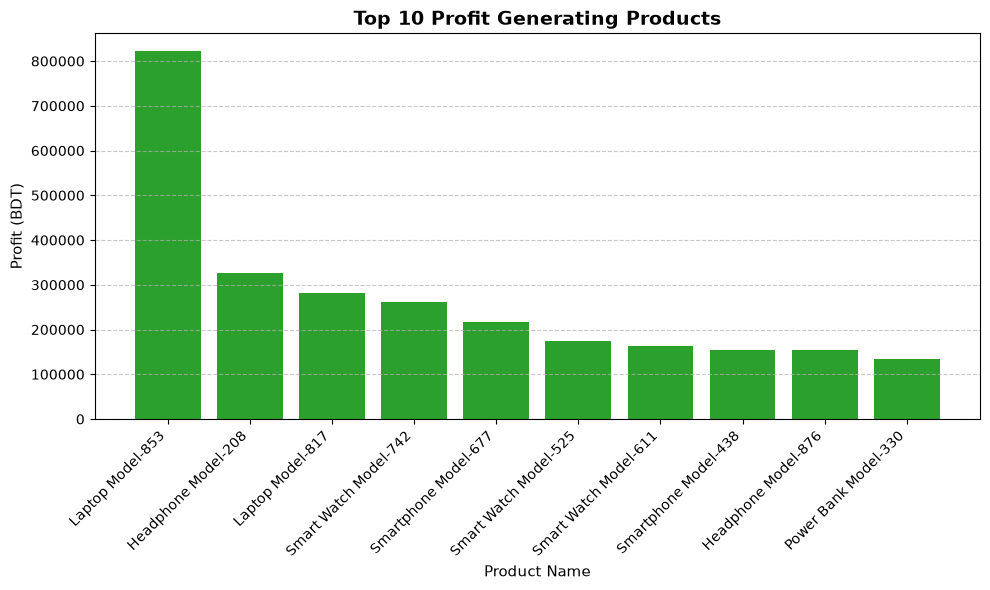

In [19]:
import matplotlib.pyplot as plt

# Data selection: Top 10 Products by Profit
top_10 = product_analysis.sort_values('Profit', ascending=False).head(10)

# Figure Setup
plt.figure(figsize=(10, 6))

# Plotting Bar Chart
plt.bar(top_10['Product_Name'], top_10['Profit'], color='#2ca02c')

# Formatting Chart
plt.title('Top 10 Profit Generating Products', fontsize=14, fontweight='bold')
plt.xlabel('Product Name', fontsize=11)
plt.ylabel('Profit (BDT)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

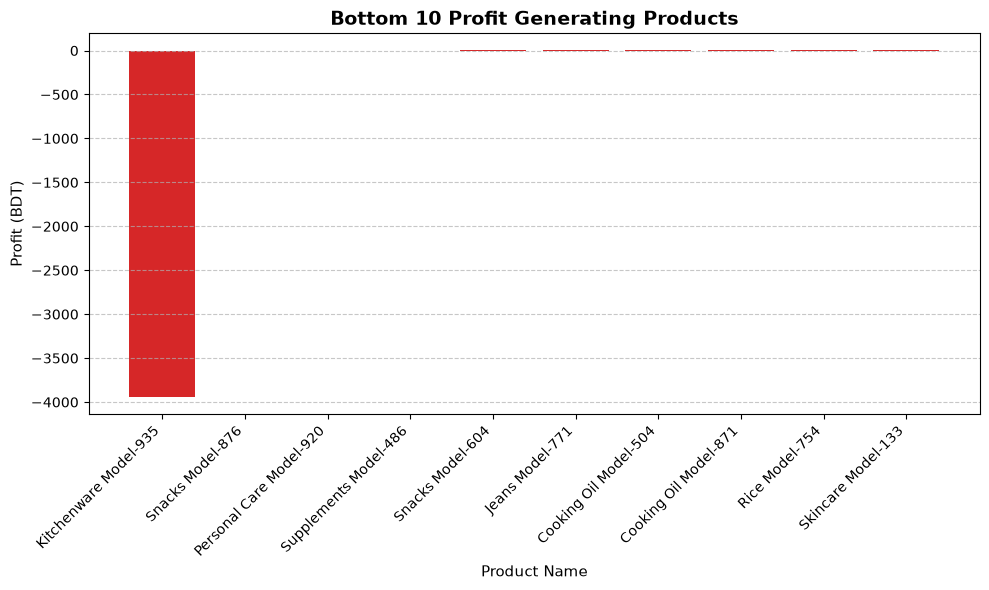

In [20]:
import matplotlib.pyplot as plt

# Data selection: Bottom 10 Products by Profit
bottom_10 = product_analysis.sort_values('Profit', ascending=True).head(10)

# Figure Setup
plt.figure(figsize=(10, 6))

# Plotting Bar Chart
plt.bar(bottom_10['Product_Name'], bottom_10['Profit'], color='#d62728')

# Formatting Chart
plt.title('Bottom 10 Profit Generating Products', fontsize=14, fontweight='bold')
plt.xlabel('Product Name', fontsize=11)
plt.ylabel('Profit (BDT)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()